# Week 5
## Topics: Multiple input features regression. 

Problems: (a) Train multiple linear regression on dataset with multiple features. 

(b) Evaluate performance metrics (R², RMSE). 

(c) Visualize residual plots. 

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
# 1. Load Data
df = pd.read_csv("regression_dataset_large.csv")


In [44]:
print(df.head())
print(df.columns)
print("\n\n",df.info())
print("\n\n",df.describe())
print(df.shape)
df.isnull().sum()

   Size_SQFT  Bedrooms  Bathrooms  Age_Years  Distance_Subway_Miles  \
0       2398         2        1.9         27                   0.16   
1       2017         1        1.0         58                   1.30   
2       2488         5        4.0         25                   2.46   
3       3013         2        1.0         44                   0.46   
4       1959         1        1.0          1                   0.82   

   School_Rating  House_Price_K  
0              8         403.99  
1              4         268.54  
2              6         467.58  
3              7         457.59  
4              4         337.18  
Index(['Size_SQFT', 'Bedrooms', 'Bathrooms', 'Age_Years',
       'Distance_Subway_Miles', 'School_Rating', 'House_Price_K'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Size_S

Size_SQFT                0
Bedrooms                 0
Bathrooms                0
Age_Years                0
Distance_Subway_Miles    0
School_Rating            0
House_Price_K            0
dtype: int64

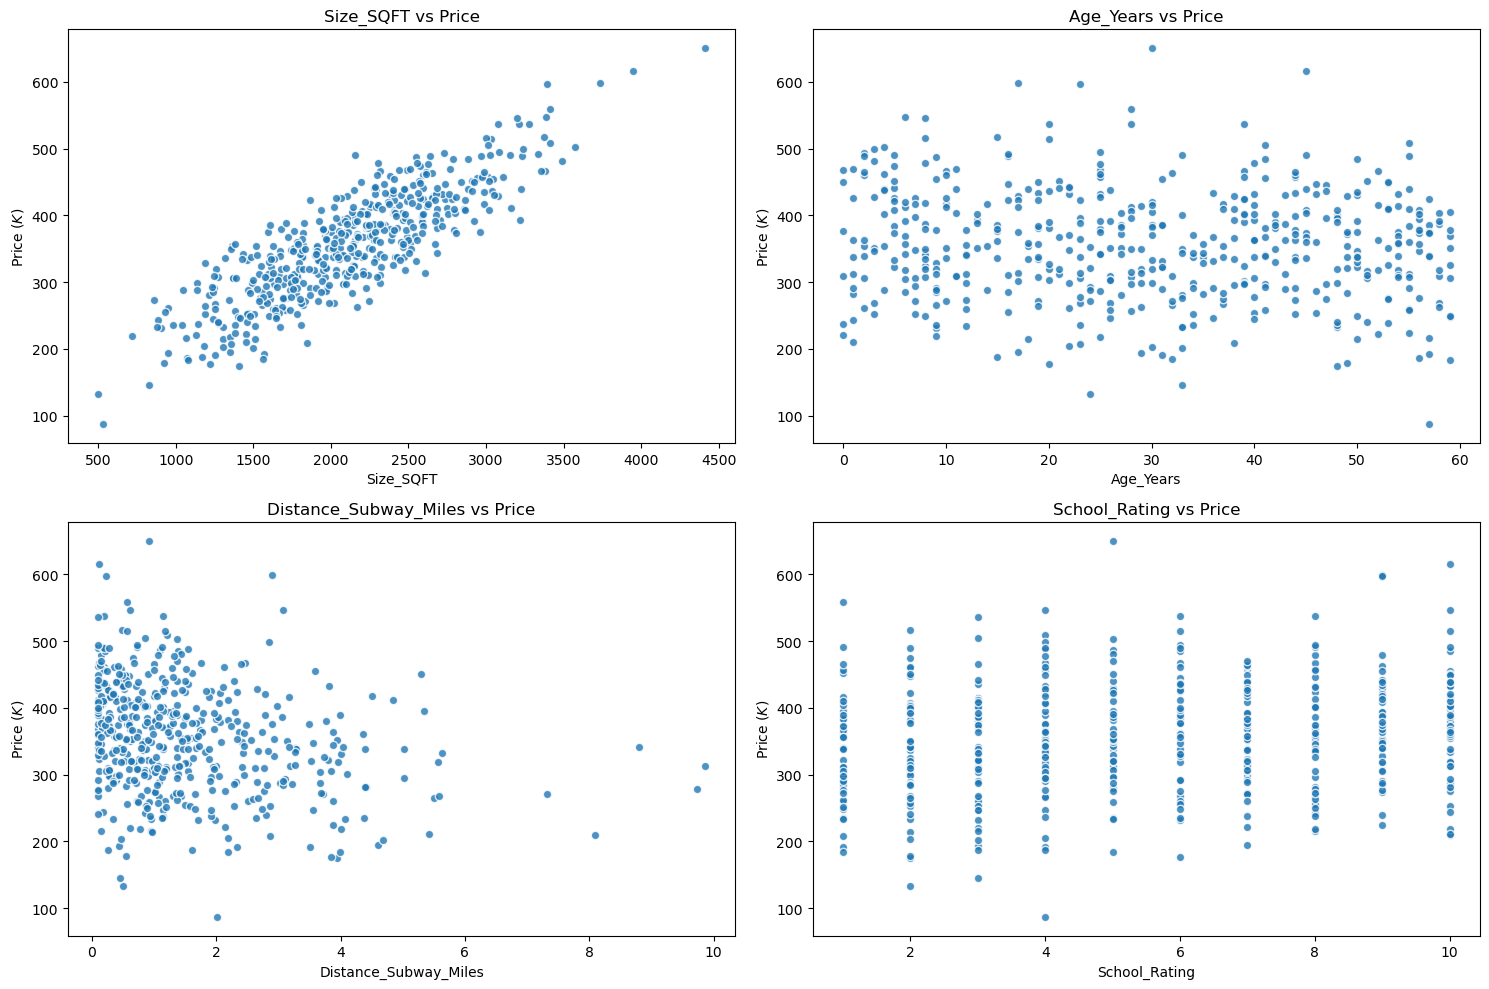

In [45]:
# Select the features you want to visualize
X_raw = ["Size_SQFT", "Age_Years", "Distance_Subway_Miles", "School_Rating"]

plt.figure(figsize=(15, 10))

for i, col in enumerate(X_raw):
    plt.subplot(2, 2, i + 1)
    # Using a sample of 500 points so the plot isn't too crowded
    plt.scatter(df[col].iloc[:500], df["House_Price_K"].iloc[:500], alpha=0.8, edgecolors='w')
    plt.title(f"{col} vs Price")
    plt.xlabel(col)
    plt.ylabel("Price (K)")

plt.tight_layout()
plt.show()

In [54]:
X_raw = df[[
    "Size_SQFT",
    "Bedrooms",
    "Bathrooms",
    "Age_Years",
    "Distance_Subway_Miles",
    "School_Rating",
]].values
Y_raw = df["House_Price_K"].values

x_train_raw,x_test_raw,y_train,y_test = train_test_split(X_raw,Y_raw,test_size = 0.2, random_state = 42)

#Normalize the data using Z-Score standardization 
#formula --> Z-Score = (x - mean)/standard deviation
X_mean = np.mean(x_train_raw, axis=0)
X_std = np.std(x_train_raw, axis=0)
x_train = (x_train_raw - X_mean) / X_std    #feature scaling 
x_test = (x_test_raw - X_mean)/X_std

In [55]:
def prediction(x,m,c):
    return np.dot(x,m) + c

In [56]:
def cost(y_actual,y_hat):
    n = len(y_actual)
    error = (y_actual - y_hat)**2
    return np.sum(error)/n

In [57]:
features = x_train[1].shape
m = np.zeros(features)     #number of input features 
c = 0
lr = 0.2
def gradient_descent(x_train,y_train,m,c,lr):
    samples = len(y_train)
    y_hat = prediction(x_train,m,c)
    error = (y_hat - y_train)
    
    dm = (2/samples) * np.dot(x_train.T,error)
    dc = (2/samples) * np.sum(error)

    m = m - (dm*lr)
    c = c - (dc*lr)

    return m,c,y_hat

In [58]:
for i in range(1000):
    m, c,y_hat = gradient_descent(x_train, y_train, m, c, lr)
    
    current_loss = cost(y_train, y_hat)
    
    if i % 100 == 0:
        print(f"Iteration {i}: Cost = {current_loss:.5f}")

print(f"\nFinal Weights: m = {np.round(m, 2)} c = {c:.4f}")

Iteration 0: Cost = 133704.86680
Iteration 100: Cost = 225.03482
Iteration 200: Cost = 225.03113
Iteration 300: Cost = 225.03113
Iteration 400: Cost = 225.03113
Iteration 500: Cost = 225.03113
Iteration 600: Cost = 225.03113
Iteration 700: Cost = 225.03113
Iteration 800: Cost = 225.03113
Iteration 900: Cost = 225.03113

Final Weights: m = [ 71.72  21.38  10.05 -13.91 -18.48  14.24] c = 355.8723


In [51]:
def get_user_prediction(user_features, m, c, X_mean, X_std):
    """
    user_features: list of raw values e.g., [2100, 3, 2, 30, 1.2, 7]
    m: trained weights
    c: trained intercept
    X_mean: The mean of the training data (saved earlier)
    X_std: The std of the training data (saved earlier)
    """
    # 1. Convert input to a numpy array
    features_array = np.array(user_features)
    
    # 2. Scale the input using training statistics
    # This is the "Normalization" step
    scaled_features = (features_array - X_mean) / X_std
    
    # 3. Predict using your existing function
    prediction_z = np.dot(scaled_features, m) + c
    
    final_price = prediction_z
    
    return final_price

my_house = [5600, 6, 2.0, 41, 2.5, 9]
# 1919	3	2.0	55	1.19	3
predicted_price = get_user_prediction(my_house, m, c, X_mean, X_std)

print(f"The predicted price for this house is: rupees {predicted_price:.2f}K")

The predicted price for this house is: rupees 812.73K


In [52]:
y_test_hat = prediction(x_test, m, c)

# 2. Calculate RMSE (Root Mean Squared Error)
mse_test = cost(y_test, y_test_hat)
rmse_test = np.sqrt(mse_test)

# 3. Calculate R² (Coefficient of Determination)
ss_res = np.sum((y_test - y_test_hat)**2)
ss_tot = np.sum((y_test - np.mean(y_test))**2)
r2_score = 1 - (ss_res / ss_tot)

print(f"Test RMSE: {rmse_test:.4f}")
print(f"Test R² Score: {r2_score:.4f}")

Test RMSE: 15.1461
Test R² Score: 0.9679


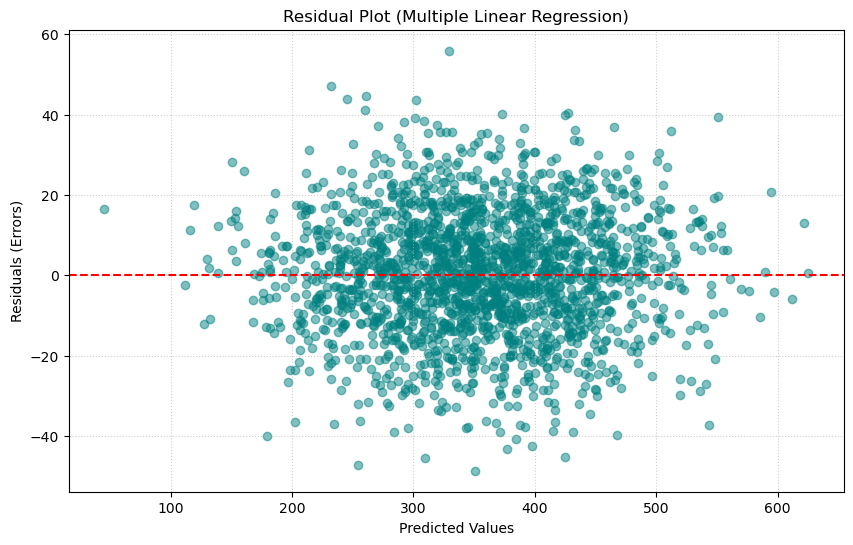

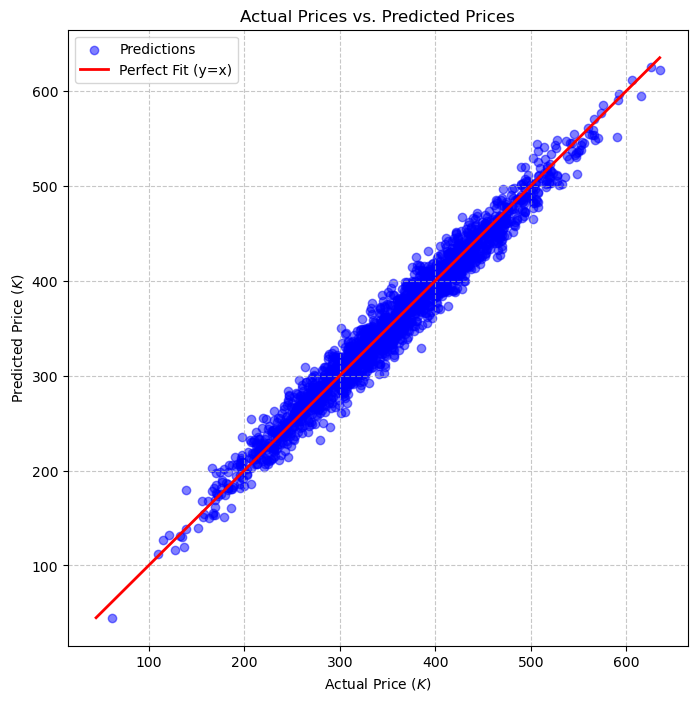

In [59]:
# Calculate residuals
residuals = y_test - y_test_hat

plt.figure(figsize=(10, 6))
plt.scatter(y_test_hat, residuals, alpha=0.5, color='teal')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot (Multiple Linear Regression)')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Errors)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
# 1. Generate predictions on the test set
y_test_hat = prediction(x_test, m, c)

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_test_hat, alpha=0.5, color='blue', label='Predictions')

# 2. Draw the "Perfect Fit" line
# This represents where the points would lie if predictions were 100% accurate
max_val = max(y_test.max(), y_test_hat.max())
min_val = min(y_test.min(), y_test_hat.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', lw=2, label='Perfect Fit (y=x)')

plt.title("Actual Prices vs. Predicted Prices")
plt.xlabel("Actual Price ($K$)")
plt.ylabel("Predicted Price ($K$)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()